In [ ]:
# PRADA-MaP seq AUROC U,G,UG

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
from Bio import SeqIO
from sklearn import metrics  

In [ ]:
## 1. Extend Figure 4m,4n,4o --- --- 

In [4]:
def convert_dot(input_file,rna): 
    sequences=[i for i in SeqIO.parse(open(input_file),'fasta')] 
    
    seq_0 = str(sequences[0].seq)
    length = len(seq_0)
    base = seq_0[0:int(length/2)]
    dot = seq_0[int(length/2):int(length)]
    
    base = list(map(lambda i:i, base))
    dot = list(map(lambda i:i, dot))
    strand = list(map(lambda i: 1 if i == "." else 0, dot))
    Nucleotide = range(1,len(strand)+1)
    
    bench = pd.DataFrame(list(zip(base,dot,strand,Nucleotide)),
              columns=['base','dot','strand','Position2'])
    bench.to_csv('./Data/'+rna+'_base_dot_strand.csv',sep='\t')
    
    return bench 

(1618, 8)
0.7669112042682926


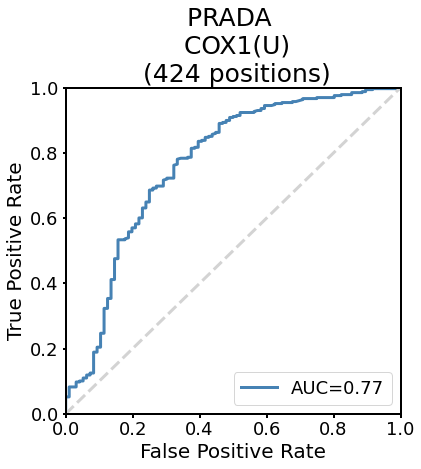

In [5]:
#### A. input 

dir = "./Data/"
prada = pd.read_csv(dir+'PRADA_vitro_4sU_mito_NC_012920.1_profile.txt',sep='\t')
cox1= prada[(prada['Nucleotide']>=5900) & (prada['Nucleotide']<=7517)]
cox1=cox1[['Nucleotide','Sequence','Modified_effective_depth','Untreated_effective_depth','Modified_rate','Untreated_rate','Reactivity_profile','Norm_profile']]
print(cox1.shape)
cox1['Nucleotide']=cox1['Nucleotide']-5899
cox1['Position2'] =cox1['Nucleotide']

#### B. bench 

dir_bench = './Data/bench/'
bench = convert_dot(dir_bench+'bench_positive_COX1_1_1618_162.dot','COX1')

#### C. combine 
df = pd.merge(cox1,bench, how='left',on=['Position2','Position2'])

#### plot Base U ------------------------------------

flt=df[(df['base']=='T') | (df['base']=='U')]

flt.to_csv('./Data/'+'source_data_Efig4m.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)

fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('PRADA \n COX1(U)'+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig4m_PRADA_COX1_baseU_AUROC.pdf',bbox_inches='tight', dpi=300) 

0.6769855072463768


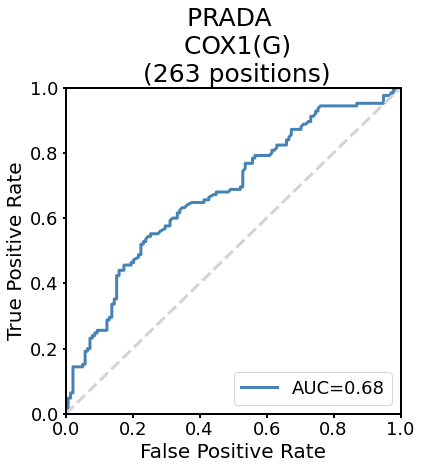

In [6]:
#### plot Base G ------------------------------------

flt=df[(df['base']=='G')]

flt.to_csv('./Data/'+'source_data_Efig4n.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)

fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('PRADA \n COX1(G)'+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig4n_PRADA_COX1_baseG_AUROC.pdf',bbox_inches='tight', dpi=300) 

0.7788202109394162


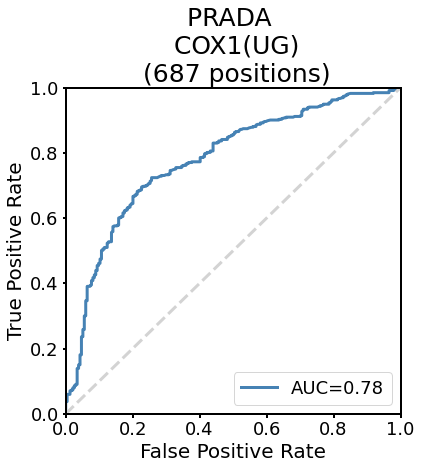

In [7]:
#### plot Base UG ------------------------------------

flt=df[(df['base']=='T') | (df['base']=='U') | (df['base']=='G')]

flt.to_csv('./Data/'+'source_data_Efig4o.csv',sep=',')

fpr_1, tpr_1, thresholds_1 = metrics.roc_curve(flt.strand, flt.Reactivity_profile, pos_label=1)
roc_auc_1 = metrics.auc(fpr_1, tpr_1)
print(roc_auc_1)

fig, (ax) = plt.subplots(1, 1, figsize = (6, 6))
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)
    ax.tick_params(width = 2)
    
plt.title('PRADA \n COX1(UG)'+'\n ('+str(flt.shape[0])+' positions)', fontsize = 25)
plt.plot(fpr_1, tpr_1, color = 'steelblue', linewidth = 3.0, label = 'AUC=%0.2f' % roc_auc_1,)

plt.legend(loc = 'lower right', fontsize = 18)
plt.plot([0, 1], [0, 1], color = 'lightgrey', linewidth = 3.0, linestyle = 'dashed')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize = 20)
plt.xlabel('False Positive Rate', fontsize = 20)
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)

dir_out = "./Data/"
plt.savefig(dir_out+'Extend_Fig4o_PRADA_COX1_baseUG_AUROC.pdf',bbox_inches='tight', dpi=300) 